# AI Powered Healthcare Shift Fill Prediction



## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np


## 2. Load the Dataset


In [2]:
df = pd.read_csv("aug_train.csv")
df.head()


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


## 3. Exploratory Data Analysis


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [4]:
df.describe(include="all")


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
count,19158.000000,19158,19158.000000,14650,19158,18772,18698,16345,19093,13220,13018,18735,19158.000000,19158.000000
unique,NaN,123,NaN,3,2,3,5,6,22,8,6,6,NaN,NaN
top,NaN,city_103,NaN,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,1,NaN,NaN
freq,NaN,4355,NaN,13221,13792,13817,11598,14492,3286,3083,9817,8040,NaN,NaN
mean,16875.358179,NaN,0.828848,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.366896,0.249348
std,9616.292592,NaN,0.123362,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.058462,0.432647
min,1.000000,NaN,0.448000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000
25%,8554.250000,NaN,0.740000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.000000,0.000000
50%,16982.500000,NaN,0.903000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47.000000,0.000000
75%,25169.750000,NaN,0.920000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.000000,0.000000


In [5]:
df.isnull().sum()


enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [6]:
df["target"].value_counts()


target
0.0    14381
1.0     4777
Name: count, dtype: int64

## 4. Clean Missing Values


In [ ]:
health_df = df.copy()

health_df["gender"] = health_df["gender"].fillna("Unknown")
health_df["enrolled_university"] = health_df["enrolled_university"].fillna("Unknown")
health_df["education_level"] = health_df["education_level"].fillna("Unknown")
health_df["major_discipline"] = health_df["major_discipline"].fillna("Unknown")
health_df["experience"] = health_df["experience"].fillna("0")
health_df["company_size"] = health_df["company_size"].fillna("Unknown")
health_df["company_type"] = health_df["company_type"].fillna("Unknown")
health_df["last_new_job"] = health_df["last_new_job"].fillna("Never")

health_df.isnull().sum()


enrollee_id               0
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
target                    0
dtype: int64

## 5. Create Healthcare Shift Features


In [8]:
np.random.seed(42)

health_df["candidate_id"] = health_df["enrollee_id"]

professions = [
    "Registered Nurse",
    "Care Assistant",
    "Physiotherapist",
    "Healthcare Assistant",
    "Support Worker",
    "Occupational Therapist"
]

health_df["profession"] = np.random.choice(professions, len(health_df))
health_df["shift_duration"] = np.random.choice([8, 12], len(health_df), p=[0.7, 0.3])
health_df["weekend_shift"] = np.random.choice(["Yes", "No"], len(health_df), p=[0.3, 0.7])
health_df["night_shift"] = np.random.choice(["Yes", "No"], len(health_df), p=[0.25, 0.75])
health_df["hourly_rate"] = np.random.randint(18, 41, len(health_df))
health_df["travel_distance"] = np.random.randint(1, 51, len(health_df))

health_df.head()


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,...,last_new_job,training_hours,target,candidate_id,profession,shift_duration,weekend_shift,night_shift,hourly_rate,travel_distance
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,Unknown,...,1,36,1.0,8949,Healthcare Assistant,8,No,No,33,13
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,...,>4,47,0.0,29725,Support Worker,8,Yes,No,33,27
2,11561,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,Unknown,...,never,83,0.0,11561,Physiotherapist,8,Yes,No,37,37
3,33241,city_115,0.789,Unknown,No relevent experience,Unknown,Graduate,Business Degree,<1,Unknown,...,never,52,1.0,33241,Support Worker,8,No,No,30,8
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,...,4,8,0.0,666,Support Worker,8,No,No,22,2


## 6. Create Difficulty, Probability, and Filled Target


In [ ]:
health_df["difficulty_score"] = 50

# Apply simple business rules
health_df.loc[health_df["night_shift"] == "Yes", "difficulty_score"] += 15
health_df.loc[health_df["weekend_shift"] == "Yes", "difficulty_score"] += 10
health_df["difficulty_score"] += (health_df["travel_distance"] / 5).astype(int)
health_df["difficulty_score"] -= ((health_df["hourly_rate"] - 18) / 2).astype(int)

health_df["difficulty_score"] = health_df["difficulty_score"].clip(0, 100)

# Lower difficulty gives a higher probability of being filled
health_df["fill_probability"] = 1 / (
    1 + np.exp((health_df["difficulty_score"] - 50) / 7)
)

# Generate a realistic binary outcome with some uncertainty
np.random.seed(42)
health_df["filled"] = (
    np.random.rand(len(health_df)) < health_df["fill_probability"]
).astype(int)

print(health_df["filled"].value_counts())
health_df[
    ["difficulty_score", "fill_probability", "filled"]
].head()


filled
0    12475
1     6683
Name: count, dtype: int64


,difficulty_score,fill_probability,filled
0,45,0.671347,1
1,58,0.241796,0
2,58,0.241796,0
3,45,0.671347,1
4,48,0.570947,1


## 7. Save the Adapted Dataset


In [10]:
health_df.to_csv("healthcare_shift_dataset.csv", index=False)
print("Dataset saved successfully!")


Dataset saved successfully!


## 8. Select API Input Features and Encode Text


In [11]:
from sklearn.preprocessing import LabelEncoder

selected_features = [
    "profession",
    "experience",
    "training_hours",
    "shift_duration",
    "weekend_shift",
    "night_shift",
    "hourly_rate",
    "travel_distance",
    "city_development_index"
]

api_df = health_df[selected_features + ["filled"]].copy()

api_encoders = {}

for column in api_df.select_dtypes(include="object").columns:
    encoder = LabelEncoder()
    api_df[column] = encoder.fit_transform(api_df[column])
    api_encoders[column] = encoder

X = api_df[selected_features]
y = api_df["filled"]

api_df.head()


,profession,experience,training_hours,shift_duration,weekend_shift,night_shift,hourly_rate,travel_distance,city_development_index,filled
0,1,22,36,8,0,0,33,13,0.920,1
1,5,7,47,8,1,0,33,27,0.776,0
2,3,16,83,8,1,0,37,37,0.624,0
3,5,21,52,8,0,0,30,8,0.789,1
4,5,22,8,8,0,0,22,2,0.767,1


## 9. Split the Data and Train the Random Forest


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Model trained successfully!
Training data: (15326, 9)
Testing data: (3832, 9)


## 10. Evaluate the Model


In [13]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, predictions))
print("ROC AUC:", roc_auc_score(y_test, probabilities))

print("\nClassification Report")
print(classification_report(y_test, predictions))

print("Confusion Matrix")
print(confusion_matrix(y_test, predictions))


Accuracy: 0.704070981210856
ROC AUC: 0.7474593165388369

Classification Report
              precision    recall  f1-score   support

           0       0.75      0.82      0.78      2495
           1       0.59      0.48      0.53      1337

    accuracy                           0.70      3832
   macro avg       0.67      0.65      0.66      3832
weighted avg       0.69      0.70      0.70      3832

Confusion Matrix
[[2054  441]
 [ 693  644]]


## 11. Feature Importance


In [14]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance


,Feature,Importance
2,training_hours,0.192073
7,travel_distance,0.169983
6,hourly_rate,0.139817
8,city_development_index,0.124297
1,experience,0.119661
5,night_shift,0.091665
0,profession,0.077119
4,weekend_shift,0.060984
3,shift_duration,0.024402


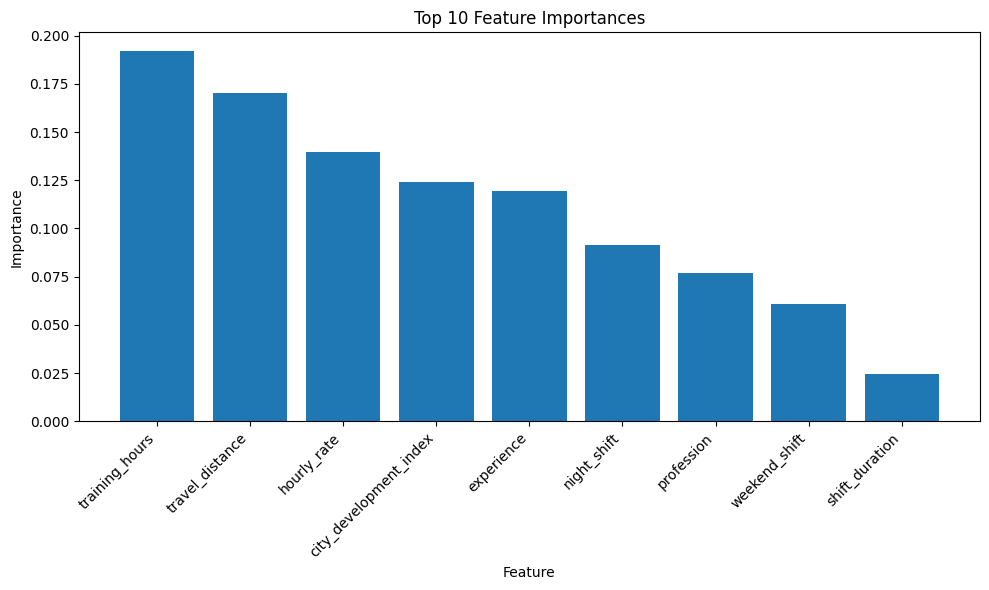

In [15]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.bar(top_features["Feature"], top_features["Importance"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Feature Importances")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


## 12. Save the Final API Model Package


In [16]:
import joblib

model_package = {
    "model": model,
    "encoders": api_encoders,
    "feature_columns": selected_features
}

joblib.dump(model_package, "shift_fill_model.pkl")

print("Final API model package saved successfully!")


Final API model package saved successfully!
